# Final Project: Nobel Prize Analysis


In [3]:
#!pip install geopandas
#!pip install geodatasets

In [4]:
# Import packages
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import re                          # For finding and extracting patterns in text
import seaborn as sns
import geopandas as gpd
import geodatasets

C:\Users\hunte\anaconda3\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been deprecated and will be removed in a future release
  "class": algorithms.Blowfish,


In [5]:
# Load data
nobel = pd.read_csv('nobel.csv')
nobel.head()

,year,category,prize,motivation,prize_share,laureate_id,laureate_type,full_name,birth_date,birth_city,birth_country,sex,organization_name,organization_city,organization_country,death_date,death_city,death_country
0,1901,Chemistry,The Nobel Prize in Chemistry 1901,"""in recognition of the extraordinary services ...",1/1,160,Individual,Jacobus Henricus van 't Hoff,1852-08-30,Rotterdam,Netherlands,Male,Berlin University,Berlin,Germany,1911-03-01,Berlin,Germany
1,1901,Literature,The Nobel Prize in Literature 1901,"""in special recognition of his poetic composit...",1/1,569,Individual,Sully Prudhomme,1839-03-16,Paris,France,Male,NaN,NaN,NaN,1907-09-07,Châtenay,France
2,1901,Medicine,The Nobel Prize in Physiology or Medicine 1901,"""for his work on serum therapy, especially its...",1/1,293,Individual,Emil Adolf von Behring,1854-03-15,Hansdorf (Lawice),Prussia (Poland),Male,Marburg University,Marburg,Germany,1917-03-31,Marburg,Germany
3,1901,Peace,The Nobel Peace Prize 1901,NaN,1/2,462,Individual,Jean Henry Dunant,1828-05-08,Geneva,Switzerland,Male,NaN,NaN,NaN,1910-10-30,Heiden,Switzerland
4,1901,Peace,The Nobel Peace Prize 1901,NaN,1/2,463,Individual,Frédéric Passy,1822-05-20,Paris,France,Male,NaN,NaN,NaN,1912-06-12,Paris,France


In [6]:
# Start of EDA
nobel.describe(include='all')

,year,category,prize,motivation,prize_share,laureate_id,laureate_type,full_name,birth_date,birth_city,birth_country,sex,organization_name,organization_city,organization_country,death_date,death_city,death_country
count,1000.000000,1000,1000,912,1000,1000.000000,1000,1000,968,964,969,970,736,735,735,596,579,585
unique,NaN,6,621,615,4,NaN,2,993,949,649,129,2,325,195,29,585,293,50
top,NaN,Medicine,The Nobel Prize in Chemistry 1972,"""for their studies of extremely fast chemical ...",1/1,NaN,Individual,Comité international de la Croix Rouge (Intern...,1932-10-24,"New York, NY",United States of America,Male,University of California,"Cambridge, MA",United States of America,2013-11-19,Paris,United States of America
freq,NaN,227,3,3,358,NaN,966,3,2,55,291,905,36,53,385,2,27,206
mean,1973.721000,NaN,NaN,NaN,NaN,509.099000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,34.523195,NaN,NaN,NaN,NaN,298.130617,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,1901.000000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,1949.750000,NaN,NaN,NaN,NaN,250.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,1979.000000,NaN,NaN,NaN,NaN,500.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,2003.000000,NaN,NaN,NaN,NaN,764.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
nobel.category.unique()

array(['Chemistry', 'Literature', 'Medicine', 'Peace', 'Physics',
       'Economics'], dtype=object)

In [8]:
nobel.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   year                  1000 non-null   int64 
 1   category              1000 non-null   object
 2   prize                 1000 non-null   object
 3   motivation            912 non-null    object
 4   prize_share           1000 non-null   object
 5   laureate_id           1000 non-null   int64 
 6   laureate_type         1000 non-null   object
 7   full_name             1000 non-null   object
 8   birth_date            968 non-null    object
 9   birth_city            964 non-null    object
 10  birth_country         969 non-null    object
 11  sex                   970 non-null    object
 12  organization_name     736 non-null    object
 13  organization_city     735 non-null    object
 14  organization_country  735 non-null    object
 15  death_date            596 non-null    o

In [9]:
# Defining a function to extract year data from different formats
def extract_year(date_value):
    if pd.isna(date_value):
        return np.nan

# If format is only a year (int/float)
    if isinstance(date_value, (int, float)):
        return int(date_value)

# If it is a string
    if isinstance(date_value, str):
        # Remove any white space
        date_str = date_value.strip()

        # case 1: Pure 4-digit year string
        if date_str.isdigit() and len(date_str) == 4:
            return int(date_str)

        # case 2: Match YYYY in various date formats
        year_match = re.search(r'(?<!\d)(\d{4})(?!\d)', date_str) # regex pattern to only extract year values matching 4 digits
        if year_match:
            return int(year_match.group(1))

    return np.nan

# Create new column for birth year
nobel['birth_year'] = nobel['birth_date'].apply(extract_year)

# Conver birth_year column to integer type (int64)
nobel['birth_year'] = nobel['birth_year'].astype('Int64') # use Int64 to handle Nan/Na values

# Create new column for birth year
nobel['death_year'] = nobel['death_date'].apply(extract_year)

# Conver birth_year column to integer type (int64)
nobel['death_year'] = nobel['death_year'].astype('Int64') # use Int64 to handle Nan/Na values

# Verify results
print("Null Birth Years:", nobel['birth_year'].isna().sum())
print("Null Death Years:", nobel['death_year'].isna().sum())
nobel.info()
print(nobel[['birth_date', 'birth_year']].tail(20))
print(nobel[['death_date', 'death_year']].head(20))

Null Birth Years: 32
Null Death Years: 404
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   year                  1000 non-null   int64 
 1   category              1000 non-null   object
 2   prize                 1000 non-null   object
 3   motivation            912 non-null    object
 4   prize_share           1000 non-null   object
 5   laureate_id           1000 non-null   int64 
 6   laureate_type         1000 non-null   object
 7   full_name             1000 non-null   object
 8   birth_date            968 non-null    object
 9   birth_city            964 non-null    object
 10  birth_country         969 non-null    object
 11  sex                   970 non-null    object
 12  organization_name     736 non-null    object
 13  organization_city     735 non-null    object
 14  organization_country  735 non-null    object
 

In [10]:
nobel.prize_share.unique()

array(['1/1', '1/2', '1/4', '1/3'], dtype=object)

In [11]:
# Encode Prize share data into factors
# with custom mapping to pre-designate codes
custom_map = {
    '1/1' : 0,
    '1/2' : 1,
    '1/3' : 2,
    '1/4' : 3
}

# Apply mapping
nobel['prize_codes'] = nobel['prize_share'].map(custom_map)

print(nobel[['prize_share', 'prize_codes']].tail(40))

    prize_share  prize_codes
960         1/2            1
961         1/2            1
962         1/2            1
963         1/2            1
964         1/4            3
965         1/4            3
966         1/2            1
967         1/2            1
968         1/2            1
969         1/1            0
970         1/2            1
971         1/2            1
972         1/2            1
973         1/4            3
974         1/4            3
975         1/3            2
976         1/1            0
977         1/3            2
978         1/3            2
979         1/3            2
980         1/3            2
981         1/3            2
982         1/1            0
983         1/3            2
984         1/3            2
985         1/3            2
986         1/3            2
987         1/3            2
988         1/3            2
989         1/2            1
990         1/2            1
991         1/3            2
992         1/3            2
993         1/

In [12]:
nobel.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   year                  1000 non-null   int64 
 1   category              1000 non-null   object
 2   prize                 1000 non-null   object
 3   motivation            912 non-null    object
 4   prize_share           1000 non-null   object
 5   laureate_id           1000 non-null   int64 
 6   laureate_type         1000 non-null   object
 7   full_name             1000 non-null   object
 8   birth_date            968 non-null    object
 9   birth_city            964 non-null    object
 10  birth_country         969 non-null    object
 11  sex                   970 non-null    object
 12  organization_name     736 non-null    object
 13  organization_city     735 non-null    object
 14  organization_country  735 non-null    object
 15  death_date            596 non-null    o

In [13]:
# Encoding sex data
nobel['sex_codes'], unique_categories = pd.factorize(nobel['sex'])
print(nobel[['sex', 'sex_codes']])

        sex  sex_codes
0      Male          0
1      Male          0
2      Male          0
3      Male          0
4      Male          0
..      ...        ...
995    Male          0
996    Male          0
997    Male          0
998  Female          1
999  Female          1

[1000 rows x 2 columns]


In [14]:
nobel.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   year                  1000 non-null   int64 
 1   category              1000 non-null   object
 2   prize                 1000 non-null   object
 3   motivation            912 non-null    object
 4   prize_share           1000 non-null   object
 5   laureate_id           1000 non-null   int64 
 6   laureate_type         1000 non-null   object
 7   full_name             1000 non-null   object
 8   birth_date            968 non-null    object
 9   birth_city            964 non-null    object
 10  birth_country         969 non-null    object
 11  sex                   970 non-null    object
 12  organization_name     736 non-null    object
 13  organization_city     735 non-null    object
 14  organization_country  735 non-null    object
 15  death_date            596 non-null    o

In [15]:
# Rename year column to year_awarded
nobel = nobel.rename(columns={'year': 'year_awarded'})
nobel.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   year_awarded          1000 non-null   int64 
 1   category              1000 non-null   object
 2   prize                 1000 non-null   object
 3   motivation            912 non-null    object
 4   prize_share           1000 non-null   object
 5   laureate_id           1000 non-null   int64 
 6   laureate_type         1000 non-null   object
 7   full_name             1000 non-null   object
 8   birth_date            968 non-null    object
 9   birth_city            964 non-null    object
 10  birth_country         969 non-null    object
 11  sex                   970 non-null    object
 12  organization_name     736 non-null    object
 13  organization_city     735 non-null    object
 14  organization_country  735 non-null    object
 15  death_date            596 non-null    o

In [16]:
# Encoding data lauriate type
nobel['laureate_code'], unique_categories = pd.factorize(nobel['laureate_type'])
print(nobel[['laureate_type', 'laureate_code']].tail(40))

    laureate_type  laureate_code
960    Individual              0
961    Individual              0
962    Individual              0
963    Individual              0
964    Individual              0
965    Individual              0
966    Individual              0
967    Individual              0
968    Individual              0
969    Individual              0
970    Individual              0
971    Individual              0
972    Individual              0
973    Individual              0
974    Individual              0
975    Individual              0
976    Individual              0
977    Individual              0
978    Individual              0
979    Individual              0
980    Individual              0
981    Individual              0
982    Individual              0
983    Individual              0
984  Organization              1
985  Organization              1
986    Individual              0
987    Individual              0
988    Individual              0
989    Ind

In [17]:
# Encoding data city of birth
nobel['birth_city_code'], unique_categories = pd.factorize(nobel['birth_city'])
print(nobel[['birth_city', 'birth_city_code']])
print(nobel['birth_city_code'].unique())

            birth_city  birth_city_code
0            Rotterdam                0
1                Paris                1
2    Hansdorf (Lawice)                2
3               Geneva                3
4                Paris                1
..                 ...              ...
995      Cleveland, OH              254
996                NaN               -1
997          Haugesund              647
998             Zanjan              648
999       New York, NY               29

[1000 rows x 2 columns]
[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  -1  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34
  35  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52
  53  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70
  71  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88
  89  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106
 107 108 109 110 111 112 113 114 115 116 117 118 119 120 

In [18]:
# Encoding data country of birth
nobel['birth_country_code'], unique_categories = pd.factorize(nobel['birth_country'])
print(nobel[['birth_country', 'birth_country_code']])
print(nobel['birth_country_code'].unique())

                birth_country  birth_country_code
0                 Netherlands                   0
1                      France                   1
2            Prussia (Poland)                   2
3                 Switzerland                   3
4                      France                   1
..                        ...                 ...
995  United States of America                  21
996         USSR (now Russia)                 127
997                    Norway                   8
998                      Iran                 106
999  United States of America                  21

[1000 rows x 2 columns]
[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  -1  15  16
  17  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34
  35  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52
  53  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70
  71  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88
  89  90  

In [19]:
# Encoding data city organization is headquartered
nobel['organization_city_code'], unique_categories = pd.factorize(nobel['organization_city'])
print(nobel[['organization_city', 'organization_city_code']])
print(nobel['organization_city_code'].unique())

    organization_city  organization_city_code
0              Berlin                       0
1                 NaN                      -1
2             Marburg                       1
3                 NaN                      -1
4                 NaN                      -1
..                ...                     ...
995      New York, NY                      26
996      New York, NY                      26
997               NaN                      -1
998               NaN                      -1
999     Cambridge, MA                      29

[1000 rows x 2 columns]
[  0  -1   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16
  17  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34
  35  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52
  53  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70
  71  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88
  89  90  91  92  93  94  95  96  97  98  99 100 101 102 1

In [20]:
# Encoding data country organization is headquartered
nobel['organization_country_code'], unique_categories = pd.factorize(nobel['organization_country'])
print(nobel[['organization_country', 'organization_country_code']])
print(nobel['organization_country_code'].unique())

         organization_country  organization_country_code
0                     Germany                          0
1                         NaN                         -1
2                     Germany                          0
3                         NaN                         -1
4                         NaN                         -1
..                        ...                        ...
995  United States of America                          9
996  United States of America                          9
997                       NaN                         -1
998                       NaN                         -1
999  United States of America                          9

[1000 rows x 2 columns]
[ 0 -1  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22
 23 24 25 26 27 28]


In [21]:
# Encoding data city of death
nobel['death_city_code'], unique_categories = pd.factorize(nobel['death_city'])
print(nobel[['death_city', 'death_city_code']])
print(nobel['death_city_code'].unique())

    death_city  death_city_code
0       Berlin                0
1     Châtenay                1
2      Marburg                2
3       Heiden                3
4        Paris                4
..         ...              ...
995        NaN               -1
996        NaN               -1
997        NaN               -1
998        NaN               -1
999        NaN               -1

[1000 rows x 2 columns]
[  0   1   2   3   4   5   6   7   8  -1   9  10  11  12  13  14  15  16
  17  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34
  35  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52
  53  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70
  71  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88
  89  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106
 107 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124
 125 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142
 143 14

In [22]:
# Encoding data country of death
nobel['death_country_code'], unique_categories = pd.factorize(nobel['death_country'])
print(nobel[['death_country', 'death_country_code']])
print(nobel['death_country_code'].unique())

    death_country  death_country_code
0         Germany                   0
1          France                   1
2         Germany                   0
3     Switzerland                   2
4          France                   1
..            ...                 ...
995           NaN                  -1
996           NaN                  -1
997           NaN                  -1
998           NaN                  -1
999           NaN                  -1

[1000 rows x 2 columns]
[ 0  1  2  3  4  5  6  7  8 -1  9 10 11 12 13 14 15 16 17 18 19 20 21 22
 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46
 47 48 49]


In [23]:
nobel.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 29 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   year_awarded               1000 non-null   int64 
 1   category                   1000 non-null   object
 2   prize                      1000 non-null   object
 3   motivation                 912 non-null    object
 4   prize_share                1000 non-null   object
 5   laureate_id                1000 non-null   int64 
 6   laureate_type              1000 non-null   object
 7   full_name                  1000 non-null   object
 8   birth_date                 968 non-null    object
 9   birth_city                 964 non-null    object
 10  birth_country              969 non-null    object
 11  sex                        970 non-null    object
 12  organization_name          736 non-null    object
 13  organization_city          735 non-null    object
 14  organizat

In [24]:
nobel['age_awarded'] = nobel['year_awarded'] - nobel['birth_year']
print(nobel['age_awarded'])

0      49
1      62
2      47
3      73
4      79
       ..
995    80
996    78
997    64
998    51
999    77
Name: age_awarded, Length: 1000, dtype: Int64


In [25]:
# Metrics of nobel prize winners age at time of award
nobel['age_awarded'].describe()

count        968.0
mean     60.268595
std      12.645274
min           17.0
25%           51.0
50%           61.0
75%           69.0
max           97.0
Name: age_awarded, dtype: Float64

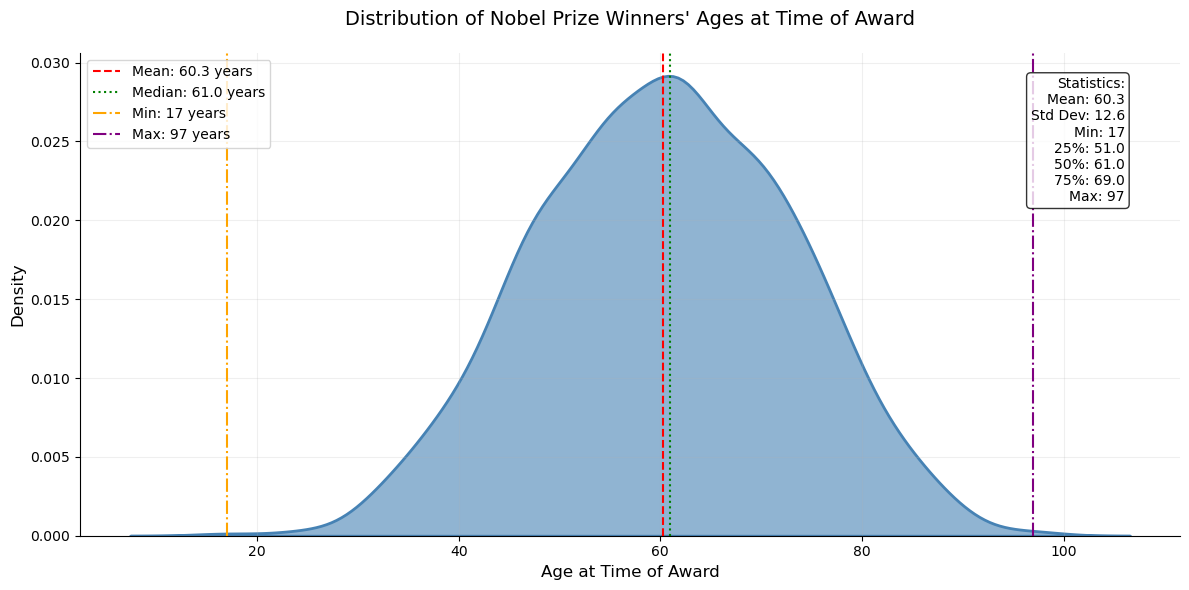

In [26]:
# Density plot of award statistics
# Calculate statistics
stats = nobel['age_awarded'].describe()
mean_age = stats['mean']
median_age = stats['50%']
min_age = stats['min']
max_age = stats['max']

# Create figure
plt.figure(figsize=(12, 6))

# Density plot
sns.kdeplot(data=nobel, x='age_awarded', fill=True, color='steelblue', alpha=0.6, linewidth=2)

# Add vertical lines for key statistics
plt.axvline(mean_age, color='red', linestyle='--', label=f'Mean: {mean_age:.1f} years')
plt.axvline(median_age, color='green', linestyle=':', label=f'Median: {median_age:.1f} years')
plt.axvline(min_age, color='orange', linestyle='-.', label=f'Min: {min_age:.0f} years')
plt.axvline(max_age, color='purple', linestyle='-.', label=f'Max: {max_age:.0f} years')

# Add text box with statistics
stats_text = f"""Statistics:
Mean: {mean_age:.1f}
Std Dev: {stats["std"]:.1f}
Min: {min_age:.0f}
25%: {stats["25%"]:.1f}
50%: {stats["50%"]:.1f}
75%: {stats["75%"]:.1f}
Max: {max_age:.0f}"""
plt.text(0.95, 0.95, stats_text, transform=plt.gca().transAxes,
         verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Customize plot
plt.title('Distribution of Nobel Prize Winners\' Ages at Time of Award', pad=20, fontsize=14)
plt.xlabel('Age at Time of Award', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend(fontsize=10, loc='upper left')
plt.grid(alpha=0.2)
sns.despine()

plt.tight_layout()
plt.show()

In [27]:
# looking at interesting observations based on age at award

# Select columns that are most relevant
age_analysis_cols = [
    'full_name',
    'sex',
    'year_awarded',
    'category',
    'prize_share',
    'birth_date',
    'age_awarded',
    'birth_city',
    'birth_country',
    'organization_name',
    'organization_country'
]

print(nobel.loc[nobel['age_awarded'] == 17, age_analysis_cols])
print(nobel.loc[nobel['age_awarded'] == 97, age_analysis_cols])

            full_name     sex  year_awarded category prize_share  birth_date  \
885  Malala Yousafzai  Female          2014    Peace         1/2  1997-07-12   

     age_awarded birth_city birth_country organization_name  \
885           17    Mingora      Pakistan               NaN   

    organization_country  
885                  NaN  
           full_name   sex  year_awarded   category prize_share  birth_date  \
942  John Goodenough  Male          2019  Chemistry         1/3  1922-07-25   

     age_awarded birth_city birth_country    organization_name  \
942           97       Jena       Germany  University of Texas   

         organization_country  
942  United States of America  


In [28]:
# Examine metrics of age distribution by award category
round(nobel.groupby('category')['age_awarded'].describe(), 1)

,count,mean,std,min,25%,50%,75%,max
category,,,,,,,,
Chemistry,193.0,59.1,12.0,35.0,50.0,58.0,68.0,97.0
Economics,93.0,66.9,8.3,47.0,61.0,67.0,72.0,90.0
Literature,120.0,65.0,10.2,42.0,57.0,67.0,73.0,88.0
Medicine,227.0,58.7,11.7,32.0,50.0,58.0,67.0,87.0
Peace,111.0,60.8,13.2,17.0,54.0,62.0,71.0,87.0
Physics,224.0,57.3,14.8,25.0,46.0,56.0,68.0,96.0


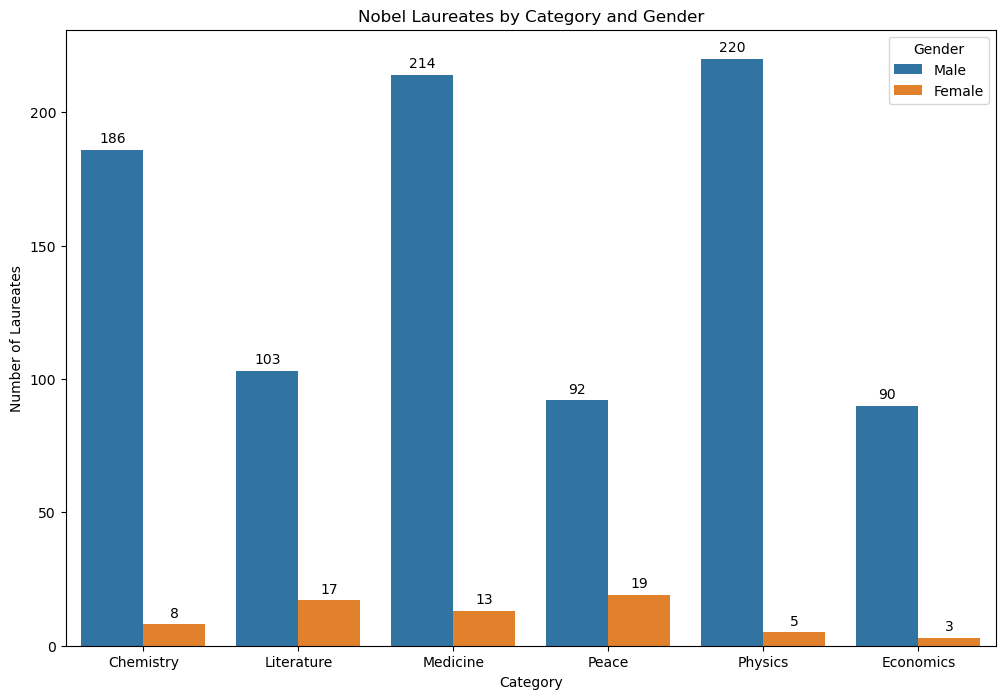

In [29]:
# Plot of counts of awards by category
plt.figure(figsize=(12,8))
ax = sns.countplot(data=nobel, x='category', hue='sex')
plt.title('Nobel Laureates by Category and Gender')
plt.xlabel('Category')
plt.ylabel('Number of Laureates')
plt.legend(title='Gender')

for container in ax.containers:
    ax.bar_label(container, label='edge', padding=3) # adds counts at bars edges
    
plt.show()

In [30]:
# Protportion of Lauriates by gender
print(nobel['sex'].value_counts())

sex
Male      905
Female     65
Name: count, dtype: int64


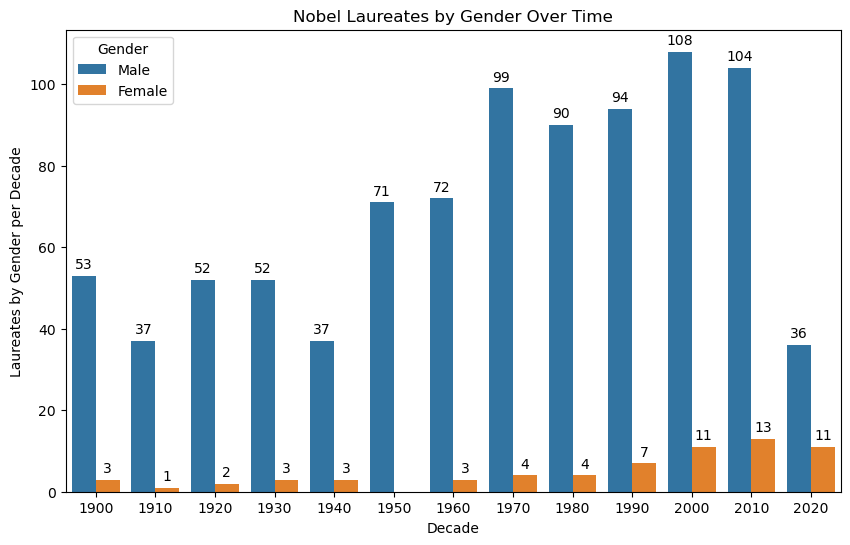

In [31]:
# create decade bins
nobel['decade'] = (nobel['year_awarded'] // 10) * 10

# Plot of gender distribution per decade
plt.figure(figsize=(10,6))
ax = sns.countplot(data=nobel, x='decade', hue='sex')
plt.title('Nobel Laureates by Gender Over Time')
plt.xlabel('Decade')
plt.ylabel('Laureates by Gender per Decade')
plt.legend(title='Gender')

for container in ax.containers:
    ax.bar_label(container, label='edge', padding=3) # adds counts at bars edges
    
plt.show()

Text(0, 0.5, 'Laureates Age at Time of Awward')

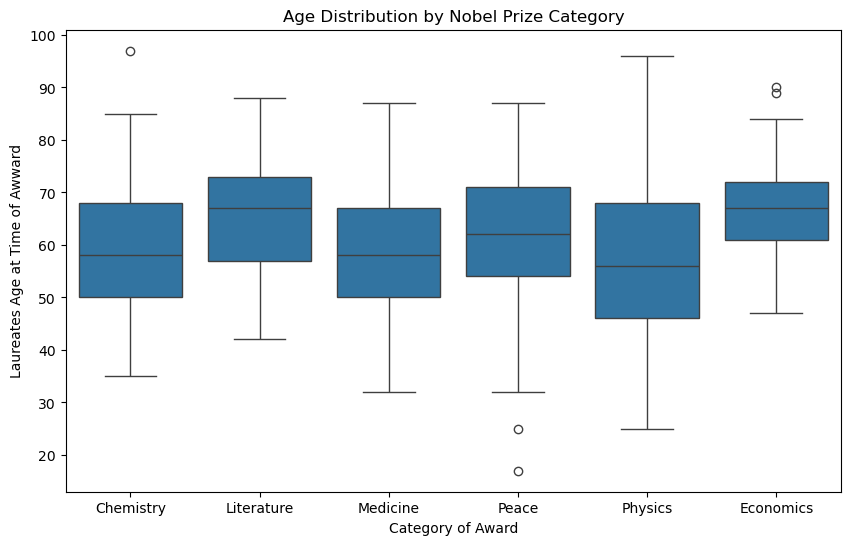

In [32]:
# plot histogram of age at time of award
plt.figure(figsize=(10,6))
sns.boxplot(data=nobel, x='category', y='age_awarded')
plt.title('Age Distribution by Nobel Prize Category')
plt.xlabel('Category of Award')
plt.ylabel('Laureates Age at Time of Awward')

birth_country
United States of America    291
United Kingdom               91
Germany                      67
France                       58
Sweden                       30
Japan                        28
Canada                       21
Switzerland                  19
Netherlands                  19
Italy                        18
Name: count, dtype: int64


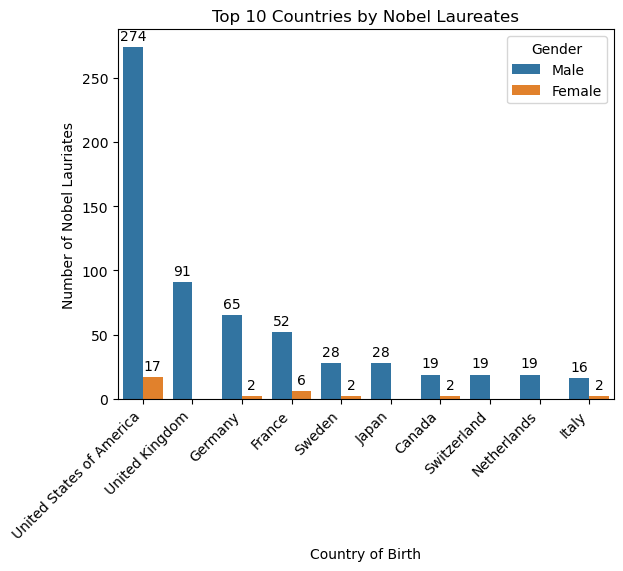

In [33]:
# Top ten countries by nobel lariate count
top_ten = nobel['birth_country'].value_counts().head(10).index
print(nobel['birth_country'].value_counts().head(10))

# Filter dataframe to allow for top ten to be graphed
filtered_nobel = nobel[nobel['birth_country'].isin(top_ten)]

# top ten nobel lauriates birth countries organized by number of awards
ax = sns.countplot(data=filtered_nobel, x='birth_country', hue='sex', order=top_ten)
plt.title('Top 10 Countries by Nobel Laureates')
plt.xlabel('Country of Birth')
plt.ylabel('Number of Nobel Lauriates')
plt.legend(title='Gender')
plt.xticks(rotation=45, ha='right')

for container in ax.containers:
    ax.bar_label(container, label='edge', padding=3) # adds counts at bars edges

plt.show()

In [34]:
nobel['birth_country'].unique()

array(['Netherlands', 'France', 'Prussia (Poland)', 'Switzerland',
       'Prussia (Germany)', 'Schleswig (Germany)', 'India', 'Sweden',
       'Norway', 'Faroe Islands (Denmark)', 'United Kingdom',
       'Russian Empire (Poland)', 'Scotland', 'Spain', 'Russia', nan,
       'Poland', 'Germany', 'Austrian Empire (Czech Republic)',
       'Hungary (Slovakia)', 'Tuscany (Italy)', 'Italy',
       'United States of America', 'Bavaria (Germany)',
       'British India (India)', 'Austrian Empire (Italy)', 'New Zealand',
       'East Friesland (Germany)', 'Russian Empire (Ukraine)', 'Denmark',
       'Luxembourg', 'Russian Empire (Latvia)', 'Belgium',
       'Hesse-Kassel (Germany)', 'Germany (Russia)',
       'Mecklenburg (Germany)', 'Austria', 'Prussia (Russia)',
       'Australia', 'Austria-Hungary (Slovenia)', 'Ireland', 'Canada',
       'Java, Dutch East Indies (Indonesia)', 'Austrian Empire (Austria)',
       'Germany (Poland)', 'W&uuml;rttemberg (Germany)', 'Argentina',
       'Austria

In [35]:
nobel['death_country'].unique()

array(['Germany', 'France', 'Switzerland', 'United Kingdom',
       'Netherlands', 'Sweden', 'Denmark', 'Spain', 'Russia', nan,
       'Austria', 'Italy', 'United States of America', 'Romania',
       'Germany (Poland)', 'India', 'Belgium', 'West Germany (Germany)',
       'Scotland', 'Norway', 'Canada', 'Poland', 'East Germany',
       'Tunisia', 'Argentina', 'Finland', 'Ireland', 'Portugal', 'Japan',
       'Jamaica', 'Northern Ireland', 'Gabon', 'Iceland',
       'Union of Soviet Socialist Republics', 'Puerto Rico',
       'Union of Soviet Socialist Republics (Russia)', 'Czechoslovakia',
       'Australia', 'South Africa', 'Yugoslavia (Serbia)',
       'Northern Rhodesia (Zambia)', 'Greece', 'Israel', 'Chile',
       'Vietnam', 'Egypt', 'Barbados', 'Mexico', 'Hungary', 'Kenya',
       'Philippines'], dtype=object)

In [36]:
# Cleaning birth country names
def clean_country_name(country):
    if pd.isna(country):
        return None
    
    # Handle special cases and historical names
    country = str(country).strip()
    
    # Common replacements
    replacements = {
        'United States of America': 'United States',
        'USA': 'United States',
        'Russian Empire': 'Russia',
        'USSR': 'Russia',
        'Union of Soviet Socialist Republics': 'Russia',
        'Prussia (Germany)': 'Germany',
        'Prussia (Poland)': 'Poland',
        'Bavaria (Germany)': 'Germany',
        'Hesse-Kassel (Germany)': 'Germany',
        'Mecklenburg (Germany)': 'Germany',
        'Württemberg (Germany)': 'Germany',
        'East Friesland (Germany)': 'Germany',
        'West Germany': 'Germany',
        'German-occupied Poland': 'Poland',
        'British India': 'India',
        'India (Pakistan)': 'Pakistan',
        'British India (Bangladesh)': 'Bangladesh',
        'Java, Dutch East Indies': 'Indonesia',
        'Ottoman Empire': 'Turkey',
        'Persia': 'Iran',
        'Burma': 'Myanmar',
        'Ceylon': 'Sri Lanka',
        'Southern Rhodesia': 'Zimbabwe',
        'Gold Coast': 'Ghana',
        'British Protectorate of Palestine': 'Israel',
        'British Mandate of Palestine': 'Israel',
        'Czechoslovakia': 'Czech Republic',
        'Austrian Empire': 'Austria',
        'Austria-Hungary': 'Austria',
        'Tibet': 'China',
        'Free City of Danzig': 'Poland',
        'Crete': 'Greece',
        'French Algeria': 'Algeria',
        'Belgian Congo': 'Democratic Republic of the Congo',
        'French protectorate of Tunisia': 'Tunisia',
        'British West Indies': 'Saint Lucia',
        'Faroe Islands': 'Denmark',
        'Scotland': 'United Kingdom',
        'Northern Ireland': 'United Kingdom',
        'Korea': 'South Korea'
    }
    
    # Check if the country contains a parenthetical
    if '(' in country:
        # Extract the modern country name from parentheses
        modern_country = country.split('(')[-1].replace(')', '').strip()
        if 'now' in modern_country:
            modern_country = modern_country.split('now')[-1].strip()
        return modern_country
    
    # Apply replacements
    for old, new in replacements.items():
        if old in country:
            return new
    
    return country

# Apply cleaning to your DataFrame
nobel['clean_country'] = nobel['birth_country'].apply(clean_country_name)

# Verify results
print(nobel[['birth_country', 'clean_country']].drop_duplicates().sort_values('clean_country'))

                    birth_country clean_country
301      French Algeria (Algeria)       Algeria
187                     Argentina     Argentina
85                      Australia     Australia
197     Austria-Hungary (Austria)       Austria
121     Austrian Empire (Austria)       Austria
..                            ...           ...
510                     Venezuela     Venezuela
435                       Vietnam       Vietnam
849                         Yemen         Yemen
326  Southern Rhodesia (Zimbabwe)      Zimbabwe
24                            NaN          None

[130 rows x 2 columns]


clean_country
United States     292
United Kingdom    106
Germany            86
France             61
Sweden             30
Russia             29
Japan              28
Poland             27
Canada             21
Italy              20
Name: count, dtype: int64


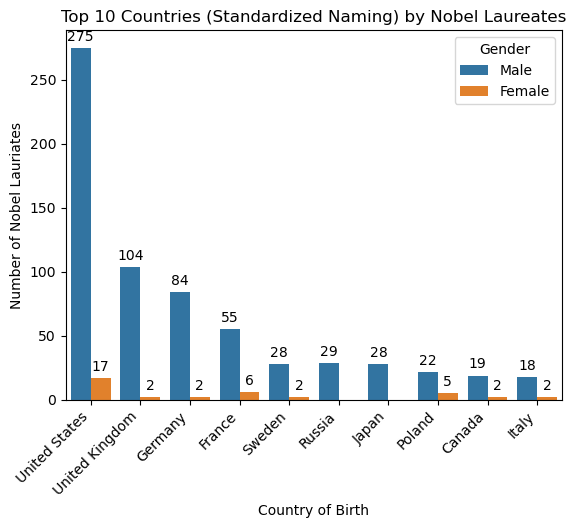

In [99]:
# Top ten countries by nobel lariate count after cleaning country names
top_ten = nobel['clean_country'].value_counts().head(10).index
print(nobel['clean_country'].value_counts().head(10))

# Filter dataframe to allow for top ten to be graphed
filtered_nobel = nobel[nobel['clean_country'].isin(top_ten)]

# top ten nobel lauriates birth countries organized by number of awards
ax = sns.countplot(data=filtered_nobel, x='clean_country', hue='sex', order=top_ten)
plt.title('Top 10 Countries (Standardized Naming) by Nobel Laureates')
plt.xlabel('Country of Birth')
plt.ylabel('Number of Nobel Lauriates')
plt.legend(title='Gender')
plt.xticks(rotation=45, ha='right')

for container in ax.containers:
    ax.bar_label(container, label='edge', padding=3) # adds counts at bars edges

plt.show()

In [38]:
# Finding out how many and who has won multiple awards
# Find multiple winners
multiple_winners = nobel['full_name'].value_counts()
multiple_winners = multiple_winners[multiple_winners > 1].index

# Display their categories
multi_winner_details = nobel[nobel['full_name'].isin(multiple_winners)]
multi_winner_details[['full_name', 'laureate_type','year_awarded','category']].sort_values('full_name')

,full_name,laureate_type,year_awarded,category
89,Comité international de la Croix Rouge (Intern...,Organization,1917,Peace
215,Comité international de la Croix Rouge (Intern...,Organization,1944,Peace
348,Comité international de la Croix Rouge (Intern...,Organization,1963,Peace
306,Frederick Sanger,Individual,1958,Chemistry
505,Frederick Sanger,Individual,1980,Chemistry
298,John Bardeen,Individual,1956,Physics
424,John Bardeen,Individual,1972,Physics
278,Linus Carl Pauling,Individual,1954,Chemistry
340,Linus Carl Pauling,Individual,1962,Peace
19,"Marie Curie, née Sklodowska",Individual,1903,Physics


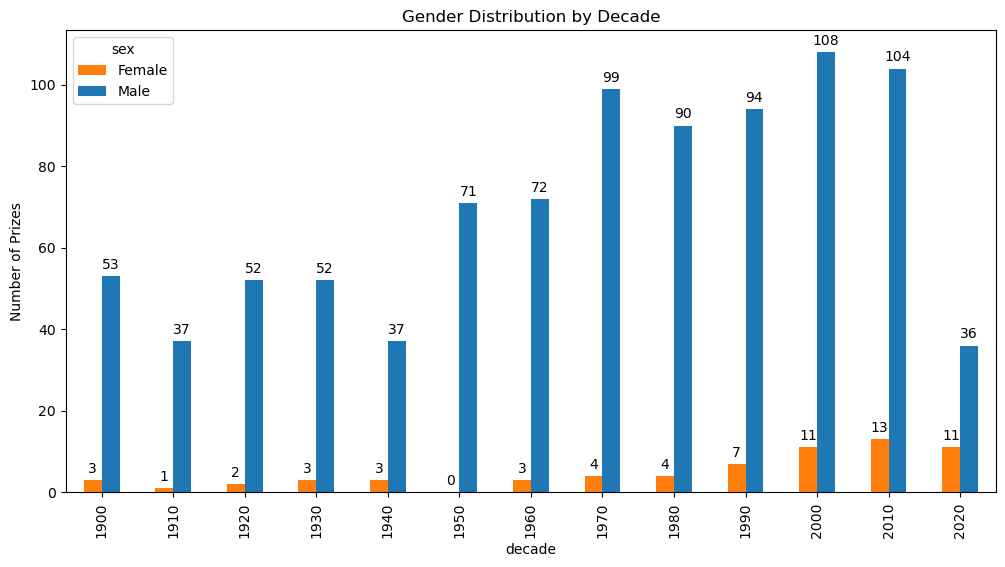

In [101]:
# Plotting gender distribution over time by decade

# Fixing colors to be consistent with other plots/graphs
color_map = {'Male' : '#1f77b4', 'Female' : '#ff7f0e'} #male = default blue, female = default orange.

gender_trend = nobel[nobel['sex'].notna()].groupby(['decade','sex']).size().unstack()
ax = gender_trend.plot(kind='bar', stacked=False, figsize=(12,6), color = color_map)
plt.title('Gender Distribution by Decade')
plt.ylabel('Number of Prizes')

for container in ax.containers:
    ax.bar_label(container, label='edge', padding=3) # adds counts at bars edges

plt.show()

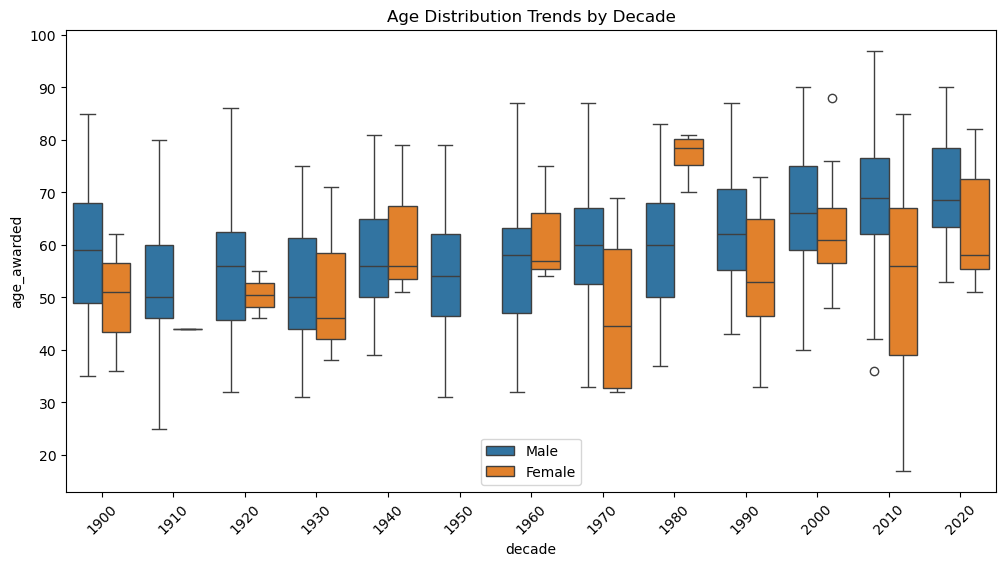

In [40]:
# Age distribution trends by decade grouped by sex
plt.figure(figsize=(12,6))
sns.boxplot(x='decade', y='age_awarded', data=nobel, hue='sex')
plt.title('Age Distribution Trends by Decade')
plt.xticks(rotation=45)
plt.legend(loc='lower center')
plt.show()

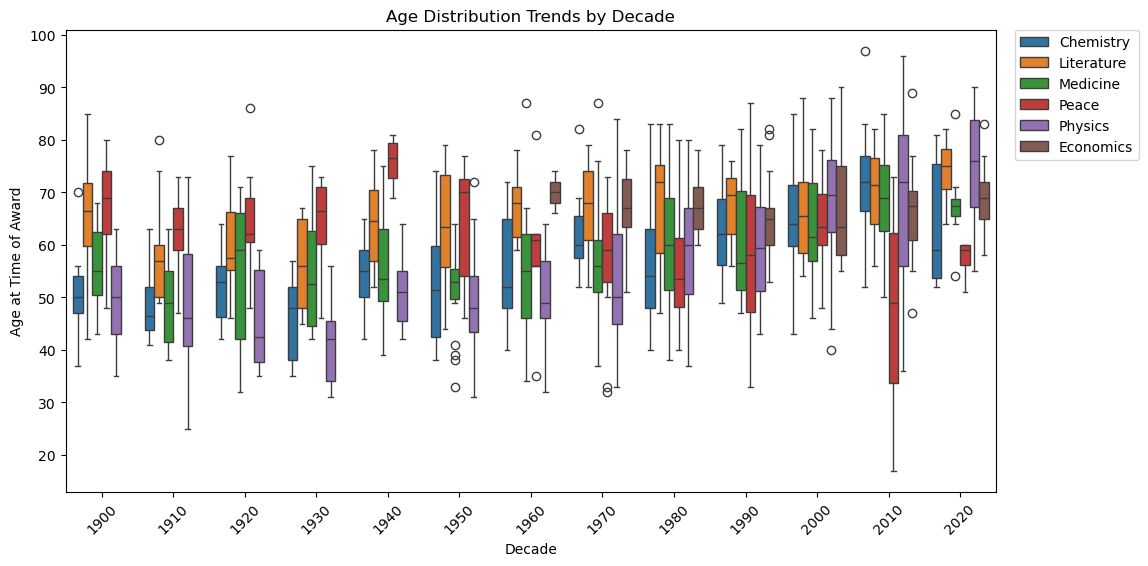

In [41]:
# Age distribution trends grouped by category
plt.figure(figsize=(12,6))
sns.boxplot(x='decade', y='age_awarded', data=nobel, hue='category')
plt.title('Age Distribution Trends by Decade')
plt.xlabel('Decade')
plt.ylabel('Age at Time of Award')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
plt.show()

clean_country  Canada  France  Germany  Italy  Japan  Poland  Russia  Sweden  \
decade                                                                         
1900              NaN     9.0      8.0    4.0    NaN     5.0     1.0     3.0   
1910              NaN     6.0      7.0    NaN    NaN     2.0     2.0     3.0   
1920              1.0     8.0     11.0    1.0    NaN     1.0     NaN     3.0   
1930              NaN     3.0      8.0    2.0    NaN     2.0     2.0     2.0   
1940              1.0     1.0      3.0    NaN    1.0     2.0     NaN     1.0   
1950              1.0     4.0      6.0    2.0    NaN     3.0     6.0     2.0   
1960              1.0     7.0      7.0    2.0    2.0     2.0     2.0     1.0   
1970              1.0     4.0      8.0    2.0    2.0     1.0     6.0     6.0   
1980              3.0     4.0     11.0    3.0    2.0     2.0     1.0     5.0   
1990              6.0     1.0      4.0    1.0    1.0     6.0     1.0     NaN   
2000              1.0     4.0      6.0  

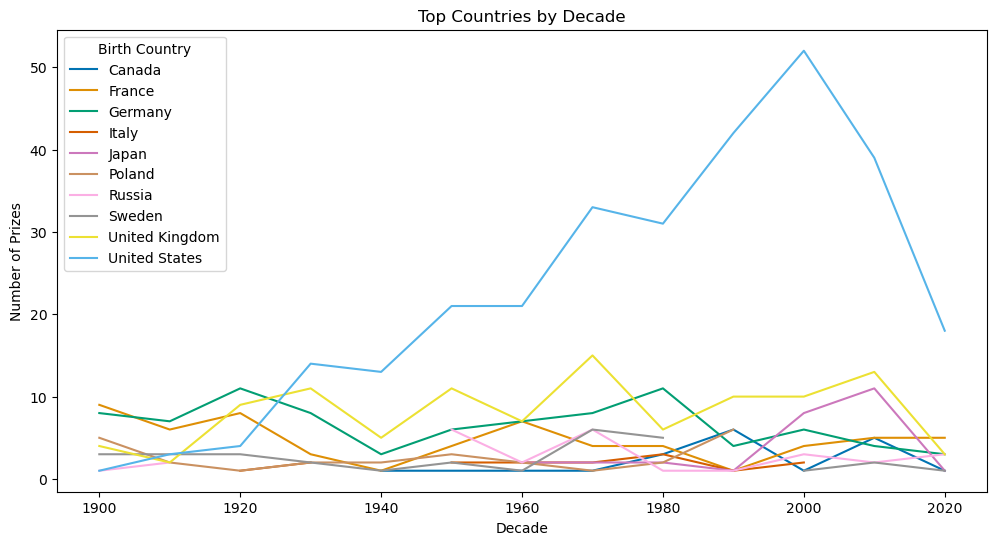

In [42]:
# Country trends over time
country_trend = nobel[nobel['clean_country'].isin(top_ten)].groupby(
    ['decade','clean_country']).size().unstack()
print(country_trend)
country_trend.plot(figsize=(12,6), color=sns.color_palette("colorblind"))
plt.title('Top Countries by Decade')
plt.xlabel('Decade')
plt.ylabel('Number of Prizes')
plt.legend(title='Birth Country')
plt.show()

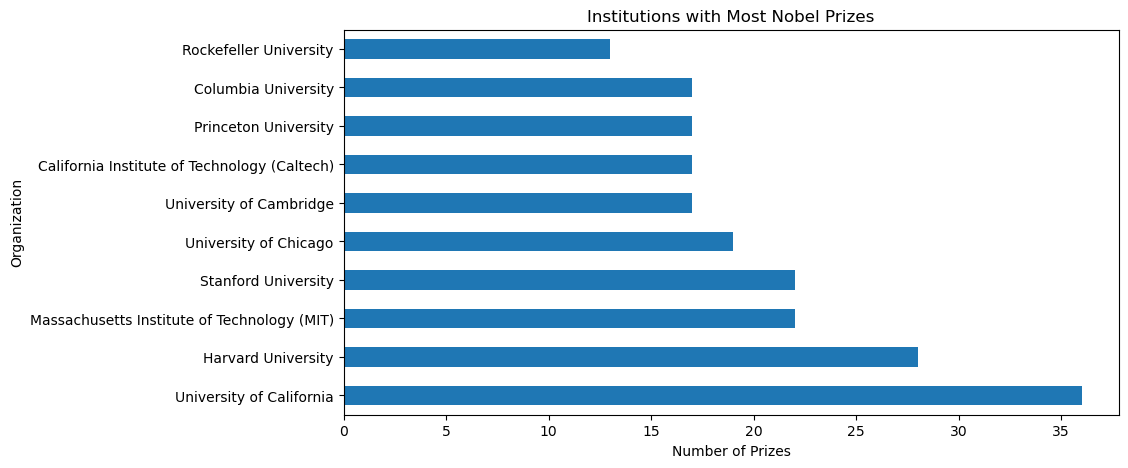

In [43]:
# Top institutions
top_orgs = nobel['organization_name'].value_counts().head(10).index
plt.figure(figsize=(10,5))
orgs_counts = nobel['organization_name'].value_counts()[top_orgs]
orgs_counts.plot(kind='barh')
plt.title('Institutions with Most Nobel Prizes')
plt.xlabel('Number of Prizes')
plt.ylabel('Organization')
plt.show()

<Figure size 1400x700 with 0 Axes>

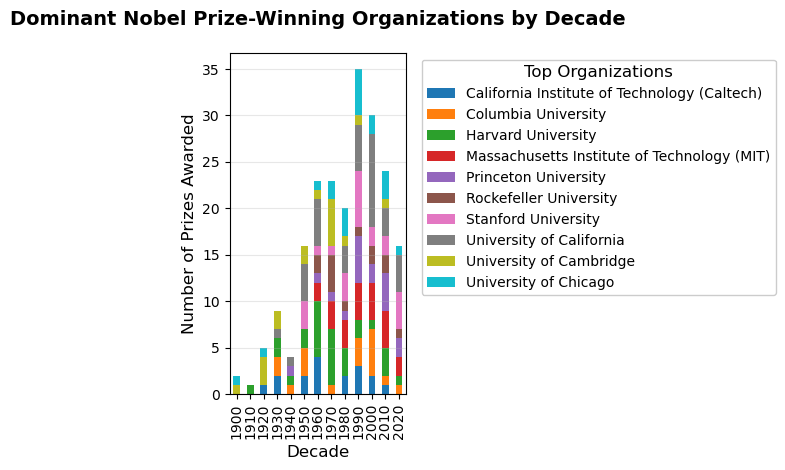

In [44]:
# Organization trends over time
# Prepare data
org_trend = nobel[nobel['organization_name'].isin(top_orgs)].groupby(
    ['decade','organization_name']).size().unstack().fillna(0)

# Set up colorblind-friendly palette
cb_palette = sns.color_palette("colorblind", n_colors=len(top_orgs))

# Create figure
plt.figure(figsize=(14, 7))

# Plot with improved styling
org_trend.plot(kind='bar', stacked=True)

# Enhance readability
plt.title('Dominant Nobel Prize-Winning Organizations by Decade', 
         pad=20, fontsize=14, weight='bold')
plt.ylabel('Number of Prizes Awarded', fontsize=12)
plt.xlabel('Decade', fontsize=12)
plt.grid(axis='y', alpha=0.3)

# Improve legend
legend = plt.legend(title='Top Organizations', bbox_to_anchor=(1.05, 1), 
                   frameon=True, framealpha=1, title_fontsize=12)

plt.tight_layout()
plt.show()

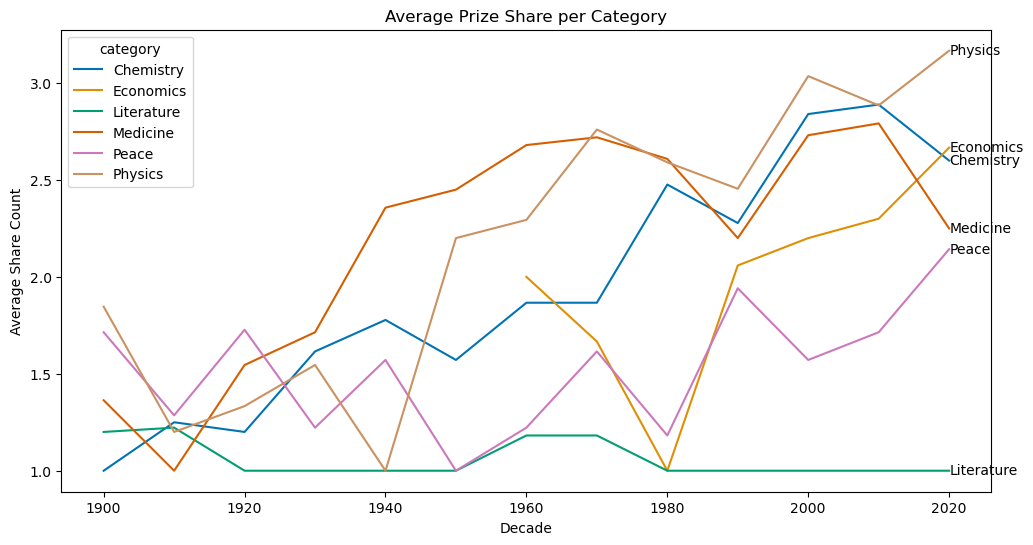

In [107]:
# Prize sharing trends
nobel['share_count'] = nobel['prize_share'].str.split('/').str[1].astype(float)
share_trend = nobel.groupby(['decade','category'])['share_count'].mean()
ax = share_trend.unstack().plot(figsize=(12,6), color=sns.color_palette("colorblind"))
plt.title('Average Prize Share per Category')
plt.xlabel('Decade')
plt.ylabel('Average Share Count')

# Add label names to lines
for line in ax.lines:
    x = line.get_xdata()[-1]
    y = line.get_ydata()[-1]
    label = line.get_label()
    ax.text(x, y, label, ha='left', va='center')

plt.show()